# Random Forest Modeling

In [2]:
from sklearn.preprocessing import StandardScaler #statndardize features by removing the mean and scaling to unit variance
from sklearn.model_selection import train_test_split #split arrays or matrices into random train and test subsets
import sys # for manipulating the Python runtime environment
import os # for interacting with the operating system

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd() # Get the current directory

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
# Ensure the parent directory is in sys.path so we can import modules from it
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from field import Field



from data_creator import load_2D
df = load_2D().dropna() # load data from files
#print("Rows before dropna:", load_2D().shape[0])
#print("Rows after dropna:", df.shape[0])
#print(df.isna().sum())

# split data into X and y

X = df[['Area', 'Circumference', 'MU', "Span" ,'CoA','MCS']]#"MCS" and 'CoA' are removed from X temporarily
y = df["AD"] > df["ADPass"]

# # scale X
scale = StandardScaler()
scaled_X = scale.fit_transform(X)

# # train test split
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 4)

/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset
gaps 16     3.29
17     4.77
18     5.62
19     6.22
20     6.51
21     6.99
22     7.10
23     7.08
24     7.98
25     8.73
26     8.69
27     9.34
28     9.81
29    10.91
30    14.62
31    15.34
32    15.42
33    15.28
34    15.19
35    15.01
36    13.29
37    12.77
38    11.92
39    12.42
40    13.60
41    13.94
42    14.02
43    13.89
44    12.79
45    12.14
46    12.53
47    11.19
48    10.80
49    10.11
50     9.46
51    10.06
52     9.80
53     9.25
54     8.96
55     8.12
56     9.69
57     9.35
58     8.39
59     7.59
60     6.84
61     6.19
62     5.54
63     5.90
64     5.03
65     2.99
66     1.98
Name: 181, dtype: float64
gaps 16     3.11
17     4.77
18     5.77
19     6.41
20     6.88
21     7.09
22     7.42
23     7.69
24     8.48
25     9.01
26     9.88
27    10.64
28    11.03
29    12.12
30    14.04
31    15.41
32    15.67
33    15.70
34    15.80
35    15.69
36    14.51
37    14

KeyboardInterrupt: 

In [ ]:

! pip install pandas


     |████████████████████████████████| 10.8 MB 8.4 MB/s eta 0:00:01
  Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# initialize random forest classifier
rfc = RandomForestClassifier()

# tune random forest parameters
param_grid = {
    'n_estimators':[5,10,15,20],
    'max_depth':[2,5,7,9]
}
grid_clf = GridSearchCV(rfc, param_grid, cv=10)
grid_clf.fit(X_train, y_train)

# fit final random forest model
final = RandomForestClassifier(n_estimators = grid_clf.best_params_["n_estimators"],
 max_depth = grid_clf.best_params_["max_depth"])
final.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, n_estimators=15)

### Results

Training ROC AUC 0.9772727272727273


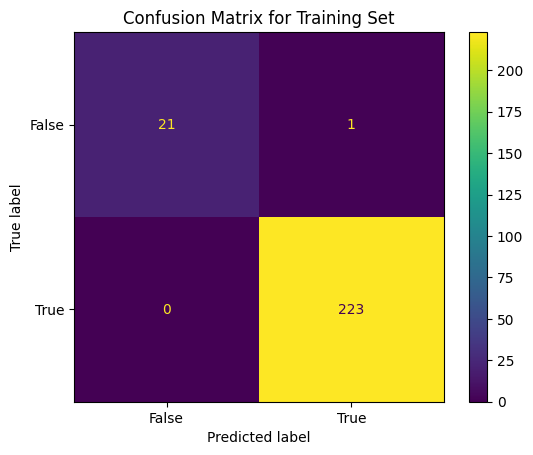

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

pred_rf = final.predict(X_train)

print("Training ROC AUC", roc_auc_score(y_train, pred_rf))
cm1 = ConfusionMatrixDisplay.from_predictions(y_train, pred_rf)
cm1.ax_.set_title("Confusion Matrix for Training Set")
plt.show()

Testing ROC AUC 0.8935064935064936


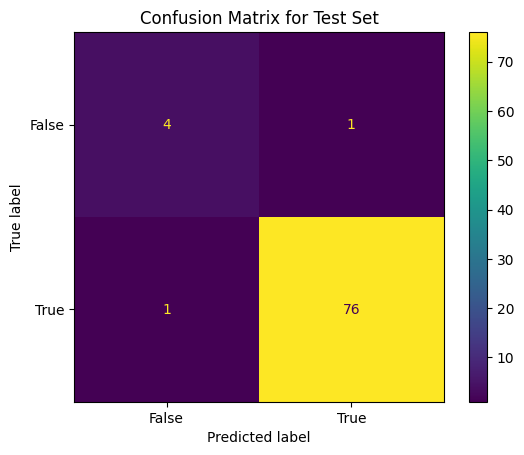

In [ ]:

rfc = RandomForestClassifier(n_estimators=10, max_depth=2)
rfc.fit(X_train, y_train)

pred_rf = final.predict(X_test)

print("Testing ROC AUC", roc_auc_score(y_test, pred_rf))
cm1 = ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
cm1.ax_.set_title("Confusion Matrix for Test Set")
plt.show()

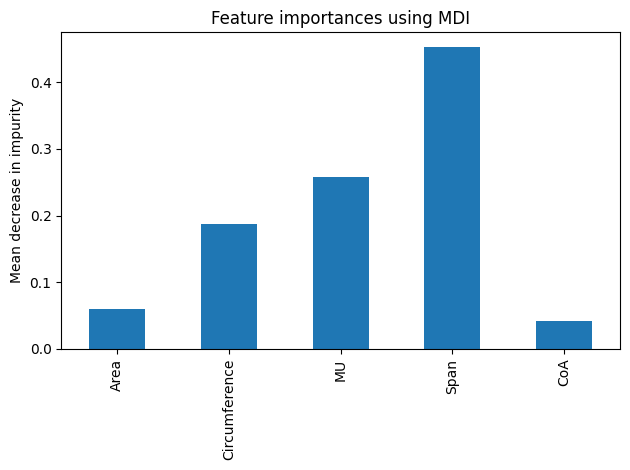

In [ ]:
# Feature Importance
feature_names = X.columns
importances = rfc.feature_importances_

import pandas as pd

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()